In [1]:
!pip install category_encoders

In [2]:
import pandas as pd
import numpy as np
import math
import heapq
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import category_encoders as ce
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, average_precision_score

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Download data from Don’tGetKicked competition.

In [4]:
!gdown 1ogHQ9uWJ-1Xl9F2jDoWAGV3Q-no6IVCq # train
!gdown 1HgOfl0D8Du1NTmpWdhd64H4wDyz8FP0M # test

Downloading...
From: https://drive.google.com/uc?id=1ogHQ9uWJ-1Xl9F2jDoWAGV3Q-no6IVCq
To: /content/training.csv
100% 14.5M/14.5M [00:00<00:00, 31.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1HgOfl0D8Du1NTmpWdhd64H4wDyz8FP0M
To: /content/test.csv
100% 9.60M/9.60M [00:00<00:00, 49.2MB/s]


## 2. Design the train/validation/test split.

- Use the "PurchDate" field for the split, test must be later than validation, same for validation and train: train.PurchDate < valid.PurchDate < test.PurchDate.
- Use the first 1/3 of dates for the train, the last 1/3 of dates for the test, and the middle 1/3 for the validation set.
- Don’t use the test dataset until the end!

In [5]:
train_data = pd.read_csv("training.csv")

In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              72983 non-null  int64  
 1   IsBadBuy                           72983 non-null  int64  
 2   PurchDate                          72983 non-null  object 
 3   Auction                            72983 non-null  object 
 4   VehYear                            72983 non-null  int64  
 5   VehicleAge                         72983 non-null  int64  
 6   Make                               72983 non-null  object 
 7   Model                              72983 non-null  object 
 8   Trim                               70623 non-null  object 
 9   SubModel                           72975 non-null  object 
 10  Color                              72975 non-null  object 
 11  Transmission                       72974 non-null  obj

In [7]:
train_data[["Model","SubModel"]].sample(8)

,Model,SubModel
13368,FREESTAR FWD V6 3.9L,PASSENGER 3.9L LX
32236,UPLANDER FWD V6,PASSENGER EXT 3.9L LS
68750,DURANGO 2WD V8 4.7L,4D SUV 4.7L ADVENTURER
67074,HHR 2.2L I-4 MPI DOH,4D SUV 2.2L LT
1970,MALIBU MAXX V6,4D SEDAN LT
46765,TAURUS 3.0L V6 EFI,4D SEDAN SE
69133,EXPEDITION 2WD V8 5.,4D SUV 5.4L XLT
30054,ION,4D SEDAN LEVEL 2


In [8]:
train_data.isna().sum()

,0
RefId,0
IsBadBuy,0
PurchDate,0
Auction,0
VehYear,0
VehicleAge,0
Make,0
Model,0
Trim,2360
SubModel,8


In [9]:
# PRIMEUNIT, AUCGUART - много NaN, удаляем фичи полностью
train_data = train_data.drop(["PRIMEUNIT", "AUCGUART"], axis=1)
# SubModel, TopAmericanName - мало NaN, удаляем пропущенные значения
# MMRCurrentRetailCleanPrice - тоже просто удаляем пропущенные (311 в сравнении с 73к это мало)
train_data = train_data.dropna(subset = ["SubModel", "TopThreeAmericanName", "MMRCurrentRetailCleanPrice"])

In [10]:
# trim, color, transmission - заменяем на наиболее часто встреч-ся (Bas)
replace_col = ["Trim", "Color", "Transmission", "Nationality", "Size"]
for col in replace_col:
  train_data[col] = train_data[col].fillna(train_data[col].mode()[0])
# "WheelType", "WheelTypeID" - связанные фичи. оставляем WheelTypeID и пропуски заполняем наиболее часто встр-ся
train_data = train_data.drop("WheelType", axis=1)
train_data["WheelTypeID"] = train_data["WheelTypeID"].fillna(train_data["WheelTypeID"].mode()[0])

In [11]:
train_data.isna().sum()

,0
RefId,0
IsBadBuy,0
PurchDate,0
Auction,0
VehYear,0
VehicleAge,0
Make,0
Model,0
Trim,0
SubModel,0


In [12]:
train_data["PurchDate"] = pd.to_datetime(train_data["PurchDate"])
train_data = train_data.sort_values(by="PurchDate")
train_data["PurchDate"] = train_data["PurchDate"].astype(int)
X = train_data.drop(["IsBadBuy"], axis=1)
Y = train_data["IsBadBuy"]

In [13]:
def tvt_split_by_time(train_df:pd.DataFrame):
  total = len(train_df)
  train_end_idx = int(total * 0.33)
  val_end_idx = int(total * 0.66)
  X = train_df.drop(["IsBadBuy"], axis=1)
  Y = train_df["IsBadBuy"]

  while X.loc[train_end_idx]["PurchDate"] == X.loc[val_end_idx]["PurchDate"]:
    val_end_idx +=1
    print(val_end_idx)

  X_train = X.iloc[:train_end_idx]
  X_valid = X.iloc[train_end_idx:val_end_idx]
  X_test = X.iloc[val_end_idx:]

  Y_train = Y.iloc[:train_end_idx]
  Y_valid = Y.iloc[train_end_idx:val_end_idx]
  Y_test = Y.iloc[val_end_idx:]
  return X_train, X_valid, X_test, Y_train, Y_valid, Y_test

In [14]:
X_train, X_valid, X_test, Y_train, Y_valid, Y_test = tvt_split_by_time(train_data)
len(X_train), len(X_valid), len(X_test)

(23977, 23977, 24705)

In [15]:
print(max(X_train["PurchDate"]))
print(max(X_valid["PurchDate"]))
print(max(X_test["PurchDate"]))

1252972800000000000
1273622400000000000
1293667200000000000


## 3. Use LabelEncoder or OneHotEncoder from sklearn to preprocess categorical variables.

- Be careful with data leakage (fit Encoder to training and apply to validation & test).
- Consider another coding approach if you encounter new categorical values in validation & test (not seen in training) - CountEncoder

In [16]:
def categories_transform(train_data:pd.DataFrame, X_train, X_valid, X_test):
  cat_cols = train_data.select_dtypes(include='object').columns.tolist()
  count_encoder = ce.CountEncoder(cols=cat_cols)
  train_encoded = count_encoder.fit_transform(X_train)
  valid_encoded = count_encoder.transform(X_valid)
  test_encoded = count_encoder.transform(X_test)
  return train_encoded, valid_encoded, test_encoded

In [17]:
train_encoded, valid_encoded, test_encoded = categories_transform(train_data, X_train, X_valid, X_test)
train_encoded.sample(5)

,RefId,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,Transmission,WheelTypeID,VehOdo,Nationality,Size,TopThreeAmericanName,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
1227,1229,1236643200000000000,4919,2004,5,5609,442,5203,4785,2438,23309,1.0,70061,20851,2926,8348,4350.0,5414.0,5198.0,6347.0,4036.0,5196.0,4859.0,6112.0,22808,38118,600,5740.0,0,1974
14139,14149,1242172800000000000,13911,2005,4,253,34,157,157,2438,23309,1.0,72973,20851,2926,8348,6415.0,8490.0,7428.0,9669.0,6415.0,8490.0,7428.0,9669.0,23359,92807,2519,6245.0,0,2208
16467,16478,1245196800000000000,13911,2002,7,186,3,24,9,1183,23309,2.0,84027,837,2950,3126,6850.0,7803.0,7898.0,8927.0,5746.0,6981.0,6706.0,8039.0,17675,32824,3356,7300.0,0,894
4637,4644,1233014400000000000,13911,2005,4,5609,231,2960,23,1992,23309,2.0,54946,20851,1185,8348,8300.0,11351.0,9464.0,12759.0,10438.0,13314.0,11773.0,14879.0,835,85040,2439,11100.0,0,920
46855,46879,1237852800000000000,13911,2005,4,547,150,410,4785,2236,23309,2.0,71700,2259,8942,3126,4216.0,5031.0,5053.0,5933.0,4411.0,5319.0,5264.0,6245.0,20207,75050,4477,4010.0,0,569


## 4. Train LogisticRegression, GaussianNB, KNN from sklearn on the training dataset and check the quality of your algorithms on the validation dataset. The dependent variable (IsBadBuy) is binary.
- Don't forget to normalize your datasets before training your models.
- You must get at least 0.15 Gini score (the best of all three). Which algorithm performs better? And why?

In [18]:
# нормализуем
sk = StandardScaler()
X_train_st = sk.fit_transform(train_encoded)
X_val_st = sk.transform(valid_encoded)
X_test_st = sk.transform(test_encoded)

In [19]:
# Logreg
logreg = LogisticRegression(penalty=None)
logreg.fit(X_train_st, Y_train)
Y_pred_proba = logreg.predict_proba(X_val_st)[:, 1]
auc_score = roc_auc_score(Y_valid, Y_pred_proba)
gini_score = 2 * auc_score - 1
print(f"{gini_score:.4f}")

0.3560


In [20]:
# NB
nb = GaussianNB()
nb.fit(X_train_st, Y_train)
Y_pred_proba = nb.predict_proba(X_val_st)[:, 1]
auc_score = roc_auc_score(Y_valid, Y_pred_proba)
gini_score = 2 * auc_score - 1
print(f"{gini_score:.4f}")

0.2950


In [21]:
# KNN
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_st, Y_train)
Y_pred_proba = knn.predict_proba(X_val_st)[:, 1]
auc_score = roc_auc_score(Y_valid, Y_pred_proba)
gini_score = 2 * auc_score - 1
print(f"{gini_score:.4f}")

0.2255


- Logreg показала сравнительно лучшие результаты, возможно, по причине природы данных: много признаков (33), есть корреляции и линейные взаимосвязи с предсказываемой переменной.
- Для успеха НБ признаки дб распределены нормально - мы далее увидим что как минимум некоторые распределены не так.
- Для успеха КНН слишком много признаков, в высокоразмерном пространстве расстояния между точками становятся одинаковыми и алгоритм теряет смысл (проклятие размерности).

In [22]:
Y_pred_proba

array([0.2, 0.1, 0. , ..., 0.1, 0.1, 0.1])

## 5. Implement Gini score calculation.
- You can use the 2*ROC AUC - 1 approach, so you need to implement the ROC AUC calculation.
- Check if your metric is approximately equal to abs(2*sklearn.metrics.roc_auc_score - 1).

In [23]:
# roc-auc через метод упорядоченных пар
def roc_auc_score_21(Y_true:np.array, Y_predicted:np.array):
  # объединяем в пары и сортируем
  pairs = np.column_stack((Y_predicted, Y_true))
  sorted_idx = np.argsort(pairs[:, 0])
  sorted_pairs = pairs[sorted_idx]
  # присваиваем ранги
  uniqs, idx = np.unique(sorted_pairs[:,0], return_index=True)
  ranks = np.zeros(len(sorted_pairs))
  for i in range(len(idx)):
    start_idx = idx[i]
    end_idx = idx[i+1] if i+1 < len(idx) else len(sorted_pairs)

    # средний ранг для группы (np.unique возвращает нам индексы краев)
    avg_rank = (start_idx +1 + end_idx) / 2
    ranks[start_idx:end_idx] = avg_rank

  pairs_ranked = np.column_stack((sorted_pairs, ranks))

  # считаем сумму рангов для Y_true == 1
  summ = pairs_ranked[pairs_ranked[:, 1] == 1][:, 2].sum()
  n_pos = np.sum(Y_true == 1)
  n_neg = len(Y_true) - n_pos

  # считаем AUC
  AUC = (summ - n_pos *(n_pos+1) / 2) / (n_pos * n_neg)

  return AUC

In [24]:
print(np.isclose(roc_auc_score_21(Y_valid, Y_pred_proba), roc_auc_score(Y_valid, Y_pred_proba)))
print(roc_auc_score(Y_valid, Y_pred_proba))

True
0.6127521153634355


In [25]:
# gini-score (нагляднее roc-auc в контексте превосходства над случайным угадыванием)
def gini_21(Y_true:np.array, Y_predicted:np.array):
  gini_score = 2 * roc_auc_score_21(Y_true, Y_predicted) - 1
  return gini_score

In [26]:
print(gini_21(Y_valid, Y_pred_proba))
print(abs(2*roc_auc_score(Y_valid, Y_pred_proba)- 1))

print(np.isclose(gini_21(Y_valid, Y_pred_proba), abs(2*roc_auc_score(Y_valid, Y_pred_proba)- 1)))

0.2255042307268713
0.2255042307268711
True


## 6. Implement your own versions of LogisticRegression, KNN and NaiveBayes classifiers.
- For LogisticRegression compute gradients with respect to the loss and use stochastic gradient descent. Can you reproduce the results from step 4?
- Guidance for this task: Your model must be represented by class with methods **fit**, **predict** (predict_proba with 0.5 threshold), **predict_proba**.
- For LR moder, compute the loss gradient with respect to parameters w and parameter b in the fit function. Use a simple **SGD** approach to estimate optimal values of parameters.

In [27]:
# Logreg
class MyLogisticRegression:

    def __init__(self, mode='stochastic', lr=0.005, iters=5000, threshold=0.5):
        self.weights = None
        np.random.seed(21)
        self.mode = mode
        self.lr = lr
        self.iters = iters
        self.threshold = threshold

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y, intercept=True):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        self.obs, self.feat = X.shape

        if intercept:
            X = np.c_[np.ones(self.obs), X]
            self.weights = np.zeros((self.feat + 1, 1))
        else:
            self.weights = np.zeros((self.feat, 1))

        # инициализация весов
        if intercept:
            y_mean = np.mean(y)
            if y_mean > 0 and y_mean < 1:
                self.weights[0] = np.log(y_mean / (1 - y_mean))

        if self.mode == "stochastic":
            for i in range(self.iters):
                self.stochastic_gradient_descent(X, y)
        else:  # non-stochastic
            for i in range(self.iters):
                self.gradient_descent(X, y)

    def gradient_descent(self, X, y):
        z = X @ self.weights
        predictions = self.sigmoid(z)

        error = predictions - y
        grad = (1 / len(y)) * X.T @ error

        self.weights -= self.lr * grad

    def stochastic_gradient_descent(self, X, y):
        batch_size = min(32, len(y))
        row_indices = np.random.choice(len(y), batch_size, replace=False)
        X_batch = X[row_indices]
        y_batch = y[row_indices]

        z = X_batch @ self.weights
        predictions = self.sigmoid(z)

        error = predictions - y_batch
        grad = (1 / batch_size) * X_batch.T @ error

        self.weights -= self.lr * grad

    def predict_proba(self, X, intercept=True):
      if self.weights is None:
          raise Exception("Модель ещё обучается")

      X = np.array(X)
      if intercept:
          X = np.c_[np.ones(len(X)), X]

      z = X @ self.weights
      prob_positive = self.sigmoid(z)
      prob_negative = 1 - prob_positive

      # обе вероятности: [P(y=0), P(y=1)]
      return np.hstack([prob_negative, prob_positive])

    def predict(self, X, intercept=True):
        probabilities = self.predict_proba(X, intercept)
        return (probabilities >= self.threshold).astype(int)

In [28]:
mylogreg = MyLogisticRegression()
mylogreg.fit(X_train_st, Y_train)
Y_pred_proba = mylogreg.predict_proba(X_val_st)[:, 1]
auc_score = roc_auc_score(Y_valid, Y_pred_proba)
gini_score = 2 * auc_score - 1
print(f"{gini_score:.4f}")
# 0.3556 было в оригинале

0.3258


In [29]:
# KNN
class MyKNN:
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
        self.X_train = None
        self.y_train = None

    def _euclidean_distance(self, X1, X2):
        return np.sqrt(np.sum((X1[:, np.newaxis] - X2) ** 2, axis=2))

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
      if self.X_train is None or self.y_train is None:
          raise Exception("Модель должна быть обучена методом fit()")

      X = np.array(X)
      n_samples = X.shape[0]
      n_classes = len(self.classes_)
      probabilities = np.zeros((n_samples, n_classes))

      distances = self._euclidean_distance(X, self.X_train)

      nearest_indices = np.argsort(distances, axis=1)[:, :self.n_neighbors]
      nearest_labels = self.y_train[nearest_indices]

      for i in range(n_samples):
          for class_idx, class_label in enumerate(self.classes_):
              probabilities[i, class_idx] = np.mean(nearest_labels[i] == class_label)

      return probabilities

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        if len(self.classes_) == 2:
            positive_proba = probabilities[:, 1]
            return (positive_proba >= threshold).astype(int)
        else:
            return self.classes_[np.argmax(probabilities, axis=1)]

In [30]:
myknn = MyKNN(n_neighbors=10)
myknn.fit(X_train_st[:1000], Y_train[:1000])
Y_pred_proba = myknn.predict_proba(X_val_st[:1000])[:, 1]
auc_score = roc_auc_score(Y_valid[:1000], Y_pred_proba)
gini_score = 2 * auc_score - 1
print(f"{gini_score:.4f}")
# 0.2255 было в оригинале

0.1801


In [31]:
class MyGaussianNB:
    def __init__(self):
        self.classes = None
        self.class_summaries = None
        self.class_priors = None

    def fit(self, X_train, y_train):
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)
        self.classes = np.unique(self.y_train)

        self.class_priors = {}
        for cls in self.classes:
            self.class_priors[cls] = np.sum(self.y_train == cls) / len(self.y_train)

        self.class_summaries = self._group_by_class(self.X_train, self.y_train)

        for cls, instances in self.class_summaries.items():
            summaries = []
            instances = np.array(instances)
            for i in range(instances.shape[1]):
                mean, std = self._mean_and_std(instances[:, i])
                summaries.append((mean, std))
            self.class_summaries[cls] = summaries

        return self

    def _group_by_class(self, X, y):
        data_dict = {}
        for i in range(len(X)):
            if y[i] not in data_dict:
                data_dict[y[i]] = []
            data_dict[y[i]].append(X[i])
        return data_dict

    def _mean_and_std(self, numbers):
        avg = np.mean(numbers)
        stddev = np.std(numbers)
        return avg, stddev

    def _calculate_gaussian_probability(self, x, mean, stdev):
        epsilon = 1e-10
        exponent = math.exp(-(math.pow(x - mean, 2) / (2 * math.pow(stdev + epsilon, 2))))
        return (1 / (math.sqrt(2 * math.pi) * (stdev + epsilon))) * exponent

    def predict_proba(self, X):
        X = np.array(X)
        probabilities = []

        for sample in X:
            sample_probs = {}
            total_prob = 0

            for cls in self.classes:
                probability = self.class_priors[cls]

                for i in range(len(sample)):
                    mean, stdev = self.class_summaries[cls][i]
                    probability *= self._calculate_gaussian_probability(sample[i], mean, stdev)

                sample_probs[cls] = probability
                total_prob += probability

            if total_prob > 0:
                for cls in sample_probs:
                    sample_probs[cls] /= total_prob

            prob_list = [sample_probs[cls] for cls in self.classes]
            probabilities.append(prob_list)

        return np.array(probabilities)

    def predict(self, X):
        proba = self.predict_proba(X)
        pred_indices = np.argmax(proba, axis=1)
        predictions = [self.classes[idx] for idx in pred_indices]

        return np.array(predictions)

In [32]:
mynb = MyGaussianNB()
mynb.fit(X_train_st, Y_train)
Y_pred_proba = mynb.predict_proba(X_val_st)[:, 1]
auc_score = roc_auc_score(Y_valid, Y_pred_proba)
gini_score = 2 * auc_score - 1
print(f"{gini_score:.4f}")
#0.2950

0.2824


## 7. Try to create non-linear features, for example:
- fractions: feature1/feature2
- groupby features: df[‘categorical_feature’].map(df.groupby(‘categorical_feature’)[‘continious_feature’].mean())

- Add new features to your pipeline, repeat step 4. Did you manage to increase your Gini score (you should!)?

In [33]:
# датафрейм фичей до всех обработок - train_data
train_data.nunique()

,0
RefId,72659
IsBadBuy,2
PurchDate,517
Auction,3
VehYear,10
VehicleAge,10
Make,33
Model,1060
Trim,134
SubModel,860


In [34]:
train_data.describe()

,RefId,IsBadBuy,PurchDate,VehYear,VehicleAge,WheelTypeID,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VehBCost,IsOnlineSale,WarrantyCost
count,72659.000000,72659.000000,7.265900e+04,72659.000000,72659.000000,72659.000000,72659.000000,72659.000000,72659.000000,72659.000000,72659.000000,72659.000000,72659.000000,72659.000000,72659.000000,72659.000000,72659.000000,72659.000000,72659.000000,72659.000000
mean,36502.212059,0.123082,1.263165e+18,2005.341238,4.180129,1.472743,71525.269684,6128.863444,7374.923547,8501.501603,9856.867546,6132.243039,7390.858889,8776.067631,10145.751208,26298.285553,58023.196507,6730.821095,0.025379,1277.075380
std,21084.344011,0.328533,1.816789e+16,1.729591,1.710415,0.519736,14567.921909,2462.449235,2723.808694,3156.157675,3386.027183,2434.547354,2686.232349,3090.543709,3310.099305,25654.757376,26160.188132,1767.905507,0.157274,599.233115
min,1.000000,0.000000,1.231114e+18,2001.000000,0.000000,0.000000,4825.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,835.000000,2764.000000,1.000000,0.000000,462.000000
25%,18231.500000,0.000000,1.248134e+18,2004.000000,3.000000,1.000000,61874.500000,4273.000000,5409.000000,6288.000000,7501.000000,4275.000000,5415.000000,6537.000000,7784.000000,17212.000000,32124.000000,5435.000000,0.000000,837.000000
50%,36509.000000,0.000000,1.264032e+18,2005.000000,4.000000,1.000000,73383.000000,6098.000000,7305.000000,8447.000000,9798.000000,6063.000000,7313.000000,8729.000000,10103.000000,19662.000000,73108.000000,6700.000000,0.000000,1169.000000
75%,54779.500000,0.000000,1.279066e+18,2007.000000,5.000000,2.000000,82452.000000,7761.000000,9024.000000,10657.000000,12092.000000,7736.000000,9013.000000,10911.000000,12309.000000,22808.000000,80022.000000,7900.000000,0.000000,1623.000000
max,73014.000000,1.000000,1.293667e+18,2010.000000,9.000000,3.000000,115717.000000,35722.000000,36859.000000,39080.000000,41482.000000,35722.000000,36859.000000,39080.000000,41062.000000,99761.000000,99224.000000,45469.000000,1.000000,7498.000000


In [35]:
# копируем датафрейм
train_data_new_feat = train_data.copy()

In [36]:
# fractions
# разница между потенциальной и фактической стоимостью
train_data_new_feat ['PriceGapRatio'] = train_data_new_feat ['VehBCost'] / (train_data_new_feat ['MMRAcquisitionRetailAveragePrice']+ 1e-10)

# пробег на год возраста
train_data_new_feat ['MilesPerYear'] = train_data_new_feat ['VehOdo'] / (train_data_new_feat ['VehicleAge'] + 1e-10)

# отношение гарантии к стоимости
train_data_new_feat ['WarrantyToCostRatio'] = train_data_new_feat ['WarrantyCost'] / (train_data_new_feat ['VehBCost'] + 1e-10)

In [37]:
train_data_new_feat.sample(5)

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,Transmission,WheelTypeID,VehOdo,Nationality,Size,TopThreeAmericanName,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost,PriceGapRatio,MilesPerYear,WarrantyToCostRatio
5866,5873,0,1278979200000000000,MANHEIM,2007,3,DODGE,CALIBER,SXT,4D WAGON SXT,BLUE,AUTO,1.0,72819,AMERICAN,MEDIUM,CHRYSLER,7083.0,8378.0,10868.0,11836.0,7058.0,8465.0,10628.0,11844.0,835,85040,AZ,6800.0,0,920,0.625690,24272.999999,0.135294
64466,64497,0,1277251200000000000,ADESA,2006,4,HYUNDAI,SONATA V6,GLS,4D SEDAN GLS,GREY,AUTO,1.0,69704,OTHER ASIAN,MEDIUM,OTHER,6545.0,7750.0,10422.0,11933.0,6407.0,7759.0,10327.0,11760.0,21053,85226,AZ,7690.0,0,728,0.737862,17426.000000,0.094668
55167,55195,0,1285027200000000000,MANHEIM,2008,2,DODGE,CHARGER V6,Bas,4D SEDAN 2.7L,BLUE,AUTO,2.0,43022,AMERICAN,SPECIALTY,CHRYSLER,10202.0,11389.0,14129.0,15472.0,10460.0,11387.0,14168.0,15152.0,20234,97217,OR,10555.0,0,975,0.747045,21510.999999,0.092373
60145,60174,0,1244764800000000000,ADESA,2005,4,BUICK,RENDEZVOUS AWD,CX,4D SUV CX,MAROON,AUTO,2.0,76436,AMERICAN,MEDIUM SUV,GM,11136.0,12938.0,12527.0,14473.0,9897.0,12798.0,11189.0,14322.0,18111,37771,TN,7140.0,0,4622,0.569969,19109.000000,0.647339
20231,20244,0,1268092800000000000,MANHEIM,2007,3,DODGE,CARAVAN GRAND FWD V6,SE,MINIVAN 3.3L,SILVER,AUTO,2.0,81994,AMERICAN,VAN,CHRYSLER,7319.0,8966.0,11333.0,12843.0,7512.0,9416.0,11502.0,13457.0,3453,80022,CO,7255.0,0,1763,0.640166,27331.333332,0.243005


In [38]:
X_train_new, X_valid_new, X_test_new, Y_train_new, Y_valid_new, Y_test_new = tvt_split_by_time(train_data_new_feat)

In [39]:
# groupby - считаем статистики на трейне, потом маппим среднюю стоимость по трейну в вал и тест
X_train_new = X_train_new.copy()
X_valid_new = X_valid_new.copy()
X_test_new = X_test_new.copy()

# заменяем Model на среднюю стоимость модели
model_avg_cost_map = X_train_new.groupby('Model')['VehBCost'].mean()
global_mean_cost = X_train_new['VehBCost'].mean()
X_train_new['Model_AvgCost'] = X_train_new['Model'].map(model_avg_cost_map).fillna(global_mean_cost)
X_valid_new['Model_AvgCost'] = X_valid_new['Model'].map(model_avg_cost_map).fillna(global_mean_cost)
X_test_new['Model_AvgCost'] = X_test_new['Model'].map(model_avg_cost_map).fillna(global_mean_cost)

In [40]:
X_train_new.sample(5)

,RefId,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,Transmission,WheelTypeID,VehOdo,Nationality,Size,TopThreeAmericanName,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost,PriceGapRatio,MilesPerYear,WarrantyToCostRatio,Model_AvgCost
16161,16172,1231891200000000000,MANHEIM,2006,3,KIA,SPECTRA 2.0L I4 EFI,EX,4D SEDAN,BLUE,AUTO,2.0,34006,OTHER ASIAN,MEDIUM,OTHER,4674.0,5709.0,5548.0,6666.0,4401.0,5120.0,5253.0,6030.0,19619,32824,FL,5100.0,0,462,0.919250,11335.333333,0.090588,5303.406114
67547,67579,1247529600000000000,ADESA,2004,5,FORD,MUSTANG V6 3.9L V6 E,Bas,2D COUPE,SILVER,AUTO,1.0,45893,AMERICAN,SPORTS,FORD,5371.0,6748.0,6301.0,7788.0,5834.0,7203.0,6801.0,8279.0,20833,78754,TX,6910.0,0,623,1.096651,9178.600000,0.090159,6592.981481
5046,5053,1249948800000000000,MANHEIM,2006,3,CHRYSLER,PT CRUISER 2.4L I4 S,Tou,4D SEDAN,SILVER,AUTO,2.0,59954,AMERICAN,MEDIUM,CHRYSLER,5427.0,6508.0,6361.0,7529.0,5033.0,5989.0,5936.0,6968.0,835,85040,AZ,5380.0,0,1086,0.845779,19984.666666,0.201859,5550.801034
65019,65050,1250553600000000000,MANHEIM,2007,2,DODGE,CARAVAN GRAND FWD V6,SE,MINIVAN 3.3L,BLUE,AUTO,2.0,88467,AMERICAN,VAN,CHRYSLER,8613.0,10859.0,9802.0,12228.0,8046.0,10111.0,9190.0,11420.0,20207,77061,TX,6645.0,0,1763,0.677923,44233.499998,0.265312,5863.391473
3026,3029,1234828800000000000,OTHER,2005,4,HYUNDAI,ELANTRA 2.0L I4 MPI,GLS,4D SEDAN,GOLD,AUTO,2.0,75761,OTHER ASIAN,MEDIUM,OTHER,4136.0,4980.0,4967.0,5878.0,4653.0,6280.0,5525.0,7282.0,20833,75061,TX,5055.0,0,569,1.017717,18940.250000,0.112562,4754.800000


In [41]:
X_train_new.describe()

,RefId,PurchDate,VehYear,VehicleAge,WheelTypeID,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VehBCost,IsOnlineSale,WarrantyCost,PriceGapRatio,MilesPerYear,WarrantyToCostRatio,Model_AvgCost
count,23977.000000,2.397700e+04,23977.000000,23977.000000,23977.000000,23977.000000,23977.000000,23977.000000,23977.000000,23977.000000,23977.000000,23977.000000,23977.000000,23977.000000,23977.000000,23977.000000,23977.000000,23977.0,23977.000000,2.397700e+04,23977.000000,23977.000000,23977.000000
mean,37458.318055,1.241957e+18,2004.816157,4.183885,1.455353,69861.517913,5794.286024,7027.919715,6750.599408,8082.957251,5842.191642,7087.664345,6931.453101,8280.165784,24317.984402,58900.950744,6355.499628,0.0,1321.183009,9.569442e+11,19556.696579,0.294520,6355.499628
std,20987.477684,6.399572e+15,1.598606,1.598666,0.517239,14278.715574,2498.340132,2790.944696,2715.724932,3033.101534,2502.084870,2793.384454,2810.761357,3121.072521,24007.828842,26229.345030,1789.196685,0.0,610.147678,8.059896e+12,9658.860757,10.267918,1579.023268
min,428.000000,1.231114e+18,2001.000000,1.000000,1.000000,5368.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,835.000000,8505.000000,1.000000,0.0,462.000000,3.221649e-04,894.666667,0.022015,1830.500000
25%,19355.000000,1.236125e+18,2004.000000,3.000000,1.000000,60438.000000,3939.000000,4993.000000,4754.000000,5892.000000,3976.000000,5076.000000,4861.000000,6050.000000,17675.000000,32124.000000,5000.000000,0.0,920.000000,8.298755e-01,13294.000000,0.137969,5264.218750
50%,37648.000000,1.241654e+18,2005.000000,4.000000,1.000000,71648.000000,5512.000000,6653.000000,6453.000000,7685.000000,5577.000000,6773.000000,6604.000000,7924.000000,19638.000000,74135.000000,6200.000000,0.0,1220.000000,9.483204e-01,17207.000000,0.195692,6074.672489
75%,56585.000000,1.247789e+18,2006.000000,5.000000,2.000000,80495.000000,7488.000000,8772.000000,8587.000000,9974.000000,7503.000000,8844.000000,8762.000000,10217.000000,21053.000000,80229.000000,7545.000000,0.0,1630.000000,1.114947e+00,22656.999999,0.274677,7488.372093
max,72860.000000,1.252973e+18,2008.000000,8.000000,3.000000,107091.000000,33543.000000,36701.000000,36726.000000,40137.000000,33369.000000,36478.000000,36539.000000,39896.000000,99761.000000,99224.000000,45469.000000,0.0,7498.000000,1.204500e+14,94818.999991,1590.000000,45469.000000


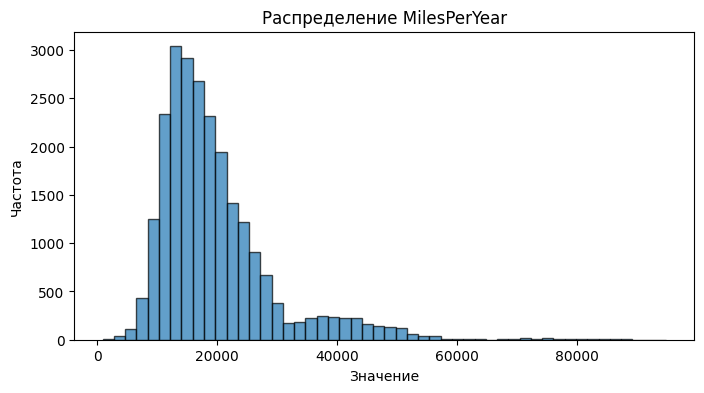

MilesPerYear: скошенность = 2.04 (сильная)


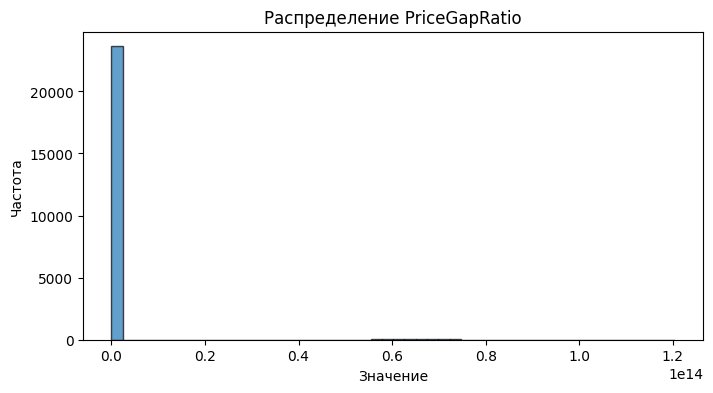

PriceGapRatio: скошенность = 8.72 (сильная)


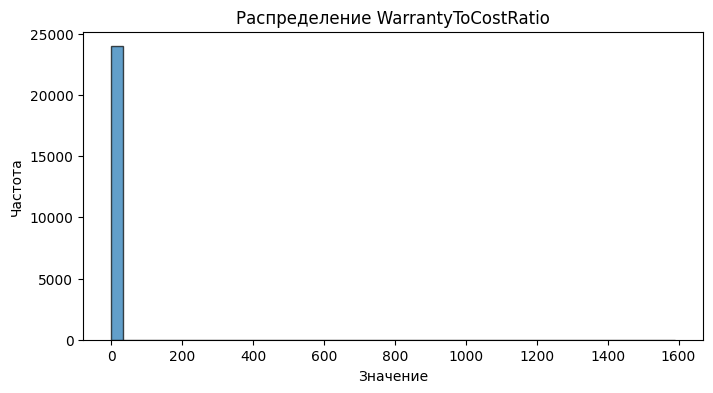

WarrantyToCostRatio: скошенность = 154.80 (сильная)


In [42]:
for feature in ['MilesPerYear', 'PriceGapRatio', 'WarrantyToCostRatio']:
    if feature in X_train_new.columns:
        plt.figure(figsize=(8, 4))
        plt.hist(X_train_new[feature].dropna(), bins=50, alpha=0.7, edgecolor='black')
        plt.title(f'Распределение {feature}')
        plt.xlabel('Значение')
        plt.ylabel('Частота')
        plt.show()

        # статистика скошенности
        skew = X_train_new[feature].skew()
        print(f"{feature}: скошенность = {skew:.2f} {'(сильная)' if abs(skew) > 1 else ''}")

In [43]:
new_features = ['PriceGapRatio', 'MilesPerYear','WarrantyToCostRatio']
if all(feat in X_train_new.columns for feat in new_features):
    corr_matrix = X_train_new[new_features].corr()
    print("Корреляция новых признаков между собой:")
    print(corr_matrix)

Корреляция новых признаков между собой:
                     PriceGapRatio  MilesPerYear  WarrantyToCostRatio
PriceGapRatio             1.000000      0.030974            -0.000916
MilesPerYear              0.030974      1.000000            -0.007030
WarrantyToCostRatio      -0.000916     -0.007030             1.000000


In [44]:
train_encoded_new, valid_encoded_new, test_encoded_new = categories_transform(train_data_new_feat, X_train_new, X_valid_new, X_test_new)

sk = StandardScaler()
X_train_st_new = sk.fit_transform(train_encoded_new)
X_val_st_new = sk.transform(valid_encoded_new)
X_test_st_new = sk.transform(test_encoded_new)

In [45]:
# Logreg - 0.3560
logreg = LogisticRegression(penalty=None)
logreg.fit(X_train_st_new, Y_train_new)
Y_pred_proba = logreg.predict_proba(X_val_st_new)[:, 1]
auc_score = roc_auc_score(Y_valid_new, Y_pred_proba)
gini_score = 2 * auc_score - 1
print(f"{gini_score:.4f}")

0.3583


In [46]:
# NB - 0.2950
nb = GaussianNB()
nb.fit(X_train_st_new, Y_train_new)
Y_pred_proba = nb.predict_proba(X_val_st_new)[:, 1]
auc_score = roc_auc_score(Y_valid_new, Y_pred_proba)
gini_score = 2 * auc_score - 1
print(f"{gini_score:.4f}")

0.2960


In [47]:
# KNN - 0.2255
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_st_new, Y_train_new)
Y_pred_proba = knn.predict_proba(X_val_st_new)[:, 1]
auc_score = roc_auc_score(Y_valid_new, Y_pred_proba)
gini_score = 2 * auc_score - 1
print(f"{gini_score:.4f}")

0.2133


- gini-score возрос незначительно для логрег и байеса, незначительно упал для KNN

## 8. Determine the best features for the problem using the coefficients of the logistic model.
- Try to eliminate useless features by hand and by L1 regularization. Which approach is better in terms of Gini score?

In [48]:
def print_coefs(model, feature_names, X_train_st, Y_train):
  X_train_df = pd.DataFrame(X_train_st, columns=feature_names)
  model.fit(X_train_df, Y_train)
  coefs = model.coef_[0]
  #feature_names = X_train.columns
  feature_importance = pd.DataFrame({
      'feature': feature_names,
      'coef': coefs,
      'abs_coef': np.abs(coefs)
  })
  feature_importance = feature_importance.sort_values('abs_coef', ascending=False)
  return feature_importance

In [49]:
# determine initial coefs and sort by desc
logreg = LogisticRegression(penalty=None, random_state=21)
feature_names = X_train.columns
feature_importance = print_coefs(logreg, feature_names, X_train_st, Y_train)
feature_importance.shape

(30, 3)

In [50]:
feature_importance

,feature,coef,abs_coef
23,MMRCurrentRetailCleanPrice,-0.354845,0.354845
20,MMRCurrentAuctionAveragePrice,0.333971,0.333971
27,VehBCost,-0.321355,0.321355
11,WheelTypeID,-0.276022,0.276022
6,Model,-0.174852,0.174852
16,MMRAcquisitionAuctionAveragePrice,0.171580,0.171580
3,VehYear,-0.161502,0.161502
4,VehicleAge,0.149520,0.149520
24,BYRNO,-0.148485,0.148485
15,TopThreeAmericanName,-0.147581,0.147581


In [51]:
# by hand
def manual_feature_selection(model, X_train, X_train_st, X_val_st, Y_train, Y_valid, threshold=0.1):
  model.fit(X_train_st, Y_train)
  coefs = np.abs(model.coef_)[0]
  selected_features_idx = np.where(coefs > threshold)[0]
  if not selected_features_idx.size > 0:
    print("No such features! Please check the threshold!")
    return (None, None)

  X_train_selected = X_train_st[:, selected_features_idx]
  X_valid_selected = X_val_st[:, selected_features_idx]

  new_model = model
  new_model.fit(X_train_selected, Y_train)

  Y_pred_proba = logreg.predict_proba(X_valid_selected)[:, 1]
  auc_score = roc_auc_score(Y_valid, Y_pred_proba)
  gini_score = 2 * auc_score - 1
  print(f"{gini_score:.4f}")

  feat_names = X_train.iloc[:,selected_features_idx].columns
  new_coefs = print_coefs(new_model, feat_names, X_train_selected, Y_train)
  return gini_score, new_coefs

In [52]:
logreg = LogisticRegression(penalty=None, random_state=21)
new_gini, manual_coefs = manual_feature_selection(logreg, X_train, X_train_st, X_val_st, Y_train, Y_valid, threshold=0.01)
manual_coefs.shape

0.3565


(27, 3)

In [53]:
manual_coefs

,feature,coef,abs_coef
21,MMRCurrentRetailCleanPrice,-0.358792,0.358792
18,MMRCurrentAuctionAveragePrice,0.340507,0.340507
25,VehBCost,-0.321657,0.321657
9,WheelTypeID,-0.277136,0.277136
14,MMRAcquisitionAuctionAveragePrice,0.173559,0.173559
5,Model,-0.172318,0.172318
3,VehYear,-0.162242,0.162242
4,VehicleAge,0.149622,0.149622
22,BYRNO,-0.148808,0.148808
13,TopThreeAmericanName,-0.146097,0.146097


In [54]:
# встроенная регуляризация
logreg = LogisticRegression(penalty='l1',C=0.45,solver='liblinear', random_state=21, max_iter=1000)

X_train_df = pd.DataFrame(X_train_st, columns=X_train.columns)
logreg.fit(X_train_df, Y_train)
X_valid_df = pd.DataFrame(X_val_st, columns=X_train.columns)
Y_pred_proba = logreg.predict_proba(X_valid_df)[:, 1]
auc_score = roc_auc_score(Y_valid, Y_pred_proba)
gini_score = 2 * auc_score - 1
print(f"{gini_score:.4f}")

non_zero_mask = np.abs(logreg.coef_[0]) > 1e-6
features_names = logreg.feature_names_in_[non_zero_mask]
X_selected = X_train_df[features_names].to_numpy()
new_coefs = print_coefs(logreg, features_names, X_selected, Y_train)

0.3515


In [55]:
new_coefs.shape

(24, 3)

In [56]:
new_coefs

,feature,coef,abs_coef
18,MMRCurrentRetailCleanPrice,-0.376217,0.376217
22,VehBCost,-0.316008,0.316008
16,MMRCurrentAuctionAveragePrice,0.309052,0.309052
3,VehYear,-0.305585,0.305585
10,WheelTypeID,-0.275618,0.275618
5,Model,-0.171421,0.171421
19,BYRNO,-0.146197,0.146197
14,TopThreeAmericanName,-0.140794,0.140794
15,MMRAcquisitionAuctionAveragePrice,0.135584,0.135584
11,VehOdo,0.124174,0.124174


- с выставляемым вручную порогом лучше, возможно, что L1 слишком сильно отбрасывает в отдельности слабо значащие, но имеющие групповой эффект с какими-то другими признаки.

## 9. Select your best model (algorithm + feature set) and tweak its hyperparameters to increase the Gini score on the validation dataset. Which hyperparameters have the most impact?

- logreg с расширенным набором фич был чуточку лучше остальных моделей.

In [57]:
!pip install optuna
import optuna

In [58]:
# Logreg, X_train_st_new, X_val_st_new
# hyperparameters - regularization

def run_logreg(trial):
    C = trial.suggest_float('C', 0.001, 10, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])

    model = LogisticRegression(
            C=C,
            penalty=penalty,
            solver='liblinear' if penalty == 'l1' else 'lbfgs',
            random_state=21,
            max_iter=1000
        )
    model.fit(X_train_st_new, Y_train_new)
    y_pred = model.predict(X_val_st_new)
    return roc_auc_score(Y_valid_new, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(run_logreg, n_trials=5)

print(f"Best roc-auc: {study.best_value:.3f}")
print(f"Best params: {study.best_params}")

[I 2025-12-12 14:02:52,212] A new study created in memory with name: no-name-0d296d4a-4919-4380-8b00-82ec04e702d6
[I 2025-12-12 14:02:52,611] Trial 0 finished with value: 0.5028902043041997 and parameters: {'C': 0.466851243223269, 'penalty': 'l2'}. Best is trial 0 with value: 0.5028902043041997.
[I 2025-12-12 14:02:58,002] Trial 1 finished with value: 0.5 and parameters: {'C': 0.009275065566077868, 'penalty': 'l1'}. Best is trial 0 with value: 0.5028902043041997.
[I 2025-12-12 14:02:58,462] Trial 2 finished with value: 0.500700711892025 and parameters: {'C': 0.003712741853479326, 'penalty': 'l2'}. Best is trial 0 with value: 0.5028902043041997.
[I 2025-12-12 14:03:00,552] Trial 3 finished with value: 0.5005893616821502 and parameters: {'C': 0.022171429078608106, 'penalty': 'l1'}. Best is trial 0 with value: 0.5028902043041997.
[I 2025-12-12 14:03:01,147] Trial 4 finished with value: 0.503049541461625 and parameters: {'C': 1.7389345172587494, 'penalty': 'l2'}. Best is trial 4 with value

Best roc-auc: 0.503
Best params: {'C': 1.7389345172587494, 'penalty': 'l2'}


In [59]:
best_model = LogisticRegression(
        C=study.best_params['C'],
        penalty=study.best_params['penalty'],
        solver='liblinear' if study.best_params['penalty'] == 'l1' else 'lbfgs',
        random_state=21,
        max_iter=1000
    )

best_model.fit(X_train_st_new, Y_train_new)

LogisticRegression(C=1.7389345172587494, max_iter=1000, random_state=21)

In [60]:
Y_pred = best_model.predict_proba(X_val_st_new)[:, 1]
gini_opt = 2 * roc_auc_score(Y_valid_new, Y_pred) - 1
print(f"Gini после оптимизации: {gini_opt:.4f}")
print(f"Улучшение: {((gini_opt - gini_score) / abs(gini_score) * 100):.1f}%")

Gini после оптимизации: 0.3581
Улучшение: 1.9%


- важные гиперпараметры - тип и сила регуляризации.

## 10. Check the Gini scores on all three datasets for your best model: training Gini, valid Gini, test Gini. Do you see a drop in performance when comparing the valid quality to the test quality? Is your model overfitted or not? Explain.

- best model - logreg

In [61]:
#gini_21(Y_true:np.array, Y_predicted:np.array):
best_model.fit(X_train_st, Y_train)

Y_pred_train = best_model.predict_proba(X_train_st)[:, 1]
gini_train = gini_21(Y_train, Y_pred_train)
print(f"Gini for train: {gini_train:.4f}")

Y_pred_val = best_model.predict_proba(X_val_st)[:, 1]
gini_valid = gini_21(Y_valid, Y_pred_val)
print(f"Gini for valid: {gini_valid:.4f}")

Y_pred_test = best_model.predict_proba(X_test_st)[:, 1]
gini_test = gini_21(Y_test, Y_pred_test)
print(f"Gini for test: {gini_test:.4f}")

Gini for train: 0.3919
Gini for valid: 0.3558
Gini for test: 0.3489


- для тестовой и валидационной выборки разница несущественна (то есть валидация репрезентативна), по сравнению с тренировочной есть уменьшение gini-score, но также маленькое. Можно сказать, что переобучения практически нет.

## 11. Implement calculation of Recall, Precision, F1 score and AUC PR metrics.
Compare your algorithms on the test dataset using AUC PR metric.


In [62]:
def precision_21(Y_true:np.ndarray, Y_exp:np.ndarray):
  if len(Y_exp) != len(Y_true):
    return ValueError("Check the sizes of input arrays!")
  tp = np.sum((Y_exp == 1) & (Y_true == 1))
  fp = np.sum((Y_exp == 1) & (Y_true == 0))

  den = tp + fp
  if den == 0:
    return 0.0
  return tp / den

In [63]:
# нужны не вероятности, а метки классов
Y_pred_test = best_model.predict(X_test_st)

# сравниваем с реализацией sklearn
print(f"My precision: {precision_21(Y_test, Y_pred_test):.4f}")
print(f"Sklearn precision: {precision_score(Y_test, Y_pred_test):.4f}")

My precision: 0.3929
Sklearn precision: 0.3929


In [64]:
def recall_21(Y_true:np.ndarray, Y_exp:np.ndarray):
  if len(Y_exp) != len(Y_true):
    return ValueError("Check the sizes of input arrays!")
  tp = np.sum((Y_exp == 1) & (Y_true == 1))
  fn = np.sum((Y_exp == 0) & (Y_true == 1))

  den = tp + fn
  if den == 0:
    return 0.0
  return tp / den

In [65]:
# сравниваем с реализацией sklearn
print(f"My recall: {recall_21(Y_test, Y_pred_test):.4f}")
print(f"Sklearn recall: {recall_score(Y_test, Y_pred_test):.4f}")

My recall: 0.0288
Sklearn recall: 0.0288


In [66]:
def auc_pr_21(Y_true: np.ndarray, Y_scores: np.ndarray):
    if len(Y_scores) != len(Y_true):
        raise ValueError("Check the sizes of input arrays!")

    # объединяем и сортируем по убыванию скора (как в roc_auc_score)
    pairs = np.column_stack((Y_scores, Y_true))
    sorted_idx = np.argsort(-pairs[:, 0])  # desc
    sorted_pairs = pairs[sorted_idx]

    scores = sorted_pairs[:, 0]
    labels = sorted_pairs[:, 1].astype(int)

    # накопленные суммы
    cumsum_positives = np.cumsum(labels)
    total_predicted_positives = np.arange(1, len(labels) + 1)

    precision_at_thresholds = cumsum_positives / total_predicted_positives
    total_real_positives = np.sum(Y_true == 1)

    if total_real_positives == 0:  # нет позитивов
        return 0.0
    recall_at_thresholds = cumsum_positives / total_real_positives

    # учет только уник порогов
    unique_score_indices = np.where(np.diff(scores) != 0)[0]
    if len(unique_score_indices) > 0:
        # по последнему индексу в каждой группе
        last_indices_in_groups = unique_score_indices
        precision_values = np.concatenate([[1.0], precision_at_thresholds[last_indices_in_groups]])
        recall_values = np.concatenate([[0.0], recall_at_thresholds[last_indices_in_groups]])
    else:
        # все скоры одинаковые
        precision_values = np.array([1.0, precision_at_thresholds[-1]])
        recall_values = np.array([0.0, recall_at_thresholds[-1]])

    # конечная точка
    precision_values = np.concatenate([precision_values, [total_real_positives / len(Y_true)]])
    recall_values = np.concatenate([recall_values, [1.0]])

    # AP = сумма(R_n - R_{n-1}) * P_n
    sorted_indices = np.argsort(recall_values)
    recall_sorted = recall_values[sorted_indices]
    precision_sorted = precision_values[sorted_indices]
    recall_diff = np.diff(recall_sorted)
    precision_right = precision_sorted[1:]

    average_precision = np.sum(recall_diff * precision_right)

    return average_precision

In [67]:
# сравниваем с реализацией sklearn
print(f"My auc_pr: {auc_pr_21(Y_test, Y_pred_test):.4f}")
print(f"Sklearn auc_pr: {average_precision_score(Y_test, Y_pred_test):.4f}")

My auc_pr: 0.1313
Sklearn auc_pr: 0.1313


## 12. Which hard label metric do you prefer for the task of detecting "lemon" cars?

- если выбирать из рассмотренных метрик, то для данного датасета, являющегося несбалансированным по положительному классу (который важен для предсказания - покупка плохих машин = зря потрачено много денег), больше всего подходит auc_pr. На тестовых данных модель показала низкое значение данной метрики (0.1313), что указывает на то, что результат не лучше случайного угадывания и легче просто спросить совета у разбирающихся в аукционах людей.